In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# importar base de datos con la que se trabajo
import pandas as pd
ruta = '/content/drive/MyDrive/Inteligencia_Artificial_1/Proyecto 1/PSCompPars_2026.02.16_14.28.02.csv'
df = pd.read_csv(ruta,comment='#')

In [ ]:
df.head(5)

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06000,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20000,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11000,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1765.03890,1.67709,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00000,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


### Variable de salida

Como nuestra variable de salida en este caso es la temperatura de equilibrio de un planeta, de modo que si se asemeja a la de la tierra "255 K", es muy probable que haya vida o que sea un planeta muy parecido a la tierra, de modo que bajo ese criterio la salida seria si es habitable o no.

Como actualmente la variable de temperatura de equilibrio es numerica y esta medida en kelvin, de modo que crearemos una variable binaria bajo el criterio de la temperatura de equilibrio `Habitabilidad_eqt`, para eso clasificaremos los datos en `habitable` / `No habitable` si cae dentro del rango de 200 - 300 K segun el proyecto parcial entregado

Siendo 1 = Habitable, 0 = No habitable

In [ ]:
# generar variable binaria
import numpy as np
df['Habitabilidad_eqt'] = np.where((df['pl_eqt'] >= 200) & (df['pl_eqt'] <= 300), 1, 0)

In [ ]:
# Conteo de planetas habitables vs no habitables
print(df['Habitabilidad_eqt'].value_counts())

# Ver los planetas habitables
print(df[df['Habitabilidad_eqt'] == 1][['pl_name', 'pl_eqt']])

Habitabilidad_eqt
0    5984
1     123
Name: count, dtype: int64
                 pl_name  pl_eqt
203            GJ 1002 b   230.9
209            GJ 1132 c   300.0
236             GJ 251 c   216.0
268             GJ 357 d   219.6
298             GJ 514 b   202.0
...                  ...     ...
5817  Teegarden's Star c   209.0
5962           WASP-41 c   241.0
5969           WASP-47 c   247.0
6044         Wolf 1069 b   250.1
6070         eps Ind A b   275.0

[123 rows x 2 columns]


Train test split

Vamos a dividir los datos en train y test, cuidando siempre que la proporcion de observaciones sea muy similar en ambos casos de 1/0

In [ ]:
from sklearn.model_selection import train_test_split

# Separar features y variable objetivo
X = df.drop(columns=['Habitabilidad_eqt'])
Y = df['Habitabilidad_eqt']

# Split 80/20 con stratify para mantener balance de clases
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Imprimir proporciones de los 3 grupos
print("Datos originales:")
print(Y.value_counts(normalize=True))

print("\nDatos de entrenamiento:")
print(Y_train.value_counts(normalize=True))

print("\nDatos de prueba:")
print(Y_test.value_counts(normalize=True))

Datos originales:
Habitabilidad_eqt
0    0.979859
1    0.020141
Name: proportion, dtype: float64

Datos de entrenamiento:
Habitabilidad_eqt
0    0.979939
1    0.020061
Name: proportion, dtype: float64

Datos de prueba:
Habitabilidad_eqt
0    0.979542
1    0.020458
Name: proportion, dtype: float64


Nota: debido a que la base de datos es bastante extensa y compleja, de modo que tenemos variables que son de tipo incertidumbre, ejemplo: 'error de radio estelar', no seria conveniente basar una metrica de prediccion en una incertidumbre, por lo que seleccionaremos un subconjunto de variables con un mayor impacto fisico, como lo es la masa del planeta, el radio, etc.

Antes de eso, rapidamente checaremos datos faltantes y outliers, para tratarlos como se debe

In [ ]:
features = ['st_rad', 'pl_insol', 'st_mass', 'st_teff', 'sy_snum']
X_train_5 = X_train[features]

# Datos faltantes por columna
print("Datos faltantes (%):")
print((X_train_5.isna().mean() * 100).round(2))

# Outliers por columna (metodo IQR)
print("\nOutliers (%):")
for col in features:
    Q1 = X_train_5[col].quantile(0.25)
    Q3 = X_train_5[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X_train_5[col] < (Q1 - 1.5 * IQR)) | (X_train_5[col] > (Q3 + 1.5 * IQR))).mean() * 100
    print(f"  {col}: {round(outliers, 2)}%")

Datos faltantes (%):
st_rad       4.95
pl_insol    30.28
st_mass      0.14
st_teff      4.50
sy_snum      0.00
dtype: float64

Outliers (%):
  st_rad: 6.31%
  pl_insol: 7.92%
  st_mass: 7.35%
  st_teff: 4.59%
  sy_snum: 9.25%


Llenar huecos y outliers SOLO a datos de train

In [ ]:
from sklearn.impute import KNNImputer

features = ['st_rad', 'pl_insol', 'st_mass', 'st_teff', 'sy_snum']
X_train_5 = X_train[features].copy()
X_test_5 = X_test[features].copy()

# Reemplazar outliers con NaN en train y test
for col in features:
    Q1 = X_train_5[col].quantile(0.25)
    Q3 = X_train_5[col].quantile(0.75)
    IQR = Q3 - Q1
    mask_train = (X_train_5[col] < (Q1 - 1.5 * IQR)) | (X_train_5[col] > (Q3 + 1.5 * IQR))
    mask_test  = (X_test_5[col]  < (Q1 - 1.5 * IQR)) | (X_test_5[col]  > (Q3 + 1.5 * IQR))
    X_train_5.loc[mask_train, col] = np.nan
    X_test_5.loc[mask_test, col]   = np.nan

# Imputar con KNN
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_5), columns=features)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test_5),      columns=features)

# Verificar resultado
print("Faltantes en train:", X_train_imputed.isna().sum().sum())
print("Faltantes en test:", X_test_imputed.isna().sum().sum())

print("\nOutliers restantes en train (%):")
for col in features:
    Q1 = X_train_imputed[col].quantile(0.25)
    Q3 = X_train_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X_train_imputed[col] < (Q1 - 1.5 * IQR)) | (X_train_imputed[col] > (Q3 + 1.5 * IQR))).mean() * 100
    print(f"  {col}: {round(outliers, 2)}%")

Faltantes en train: 0
Faltantes en test: 0

Outliers restantes en train (%):
  st_rad: 2.21%
  pl_insol: 7.14%
  st_mass: 0.14%
  st_teff: 1.45%
  sy_snum: 0.0%


Bien, parece que ya no tenemos outliers significativos ni datos faltantes, ahora midamos la exactitud de un modelo de regresión logistica usando el subconjunto seleccionado

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Modelo
model = LogisticRegression(penalty=None, class_weight='balanced', random_state=42)

# Validacion cruzada 5 folds
scores = cross_val_score(model, X_train_scaled, Y_train, cv=5, scoring='accuracy')

print("Exactitud por fold:", np.round(scores, 4))
print("Exactitud promedio:", round(scores.mean(), 4))
print("Desviacion estandar:", round(scores.std(), 4))

Exactitud por fold: [0.6346 0.652  0.653  0.6612 0.6643]
Exactitud promedio: 0.653
Desviacion estandar: 0.0103


Vemos que la exactitud promedio del modelo es de 0.653, es decir, el modelo clasifica correctamente el 65.3% de los planetas, con una desviación estandar de 0.0103, por lo que podemos decir que los resultados son aceptables.

Ahora, que tal si ahora utilizamos todo el subconjunto de datos de training, para generar un vector de probabilidades para los datos de training, junto con una matriz de confusion, donde probemos la sensibilidad del modelo en 3 distintos umbrales, usemos 0.3, 0.5 y 0.7, para ver que tal reacciona.

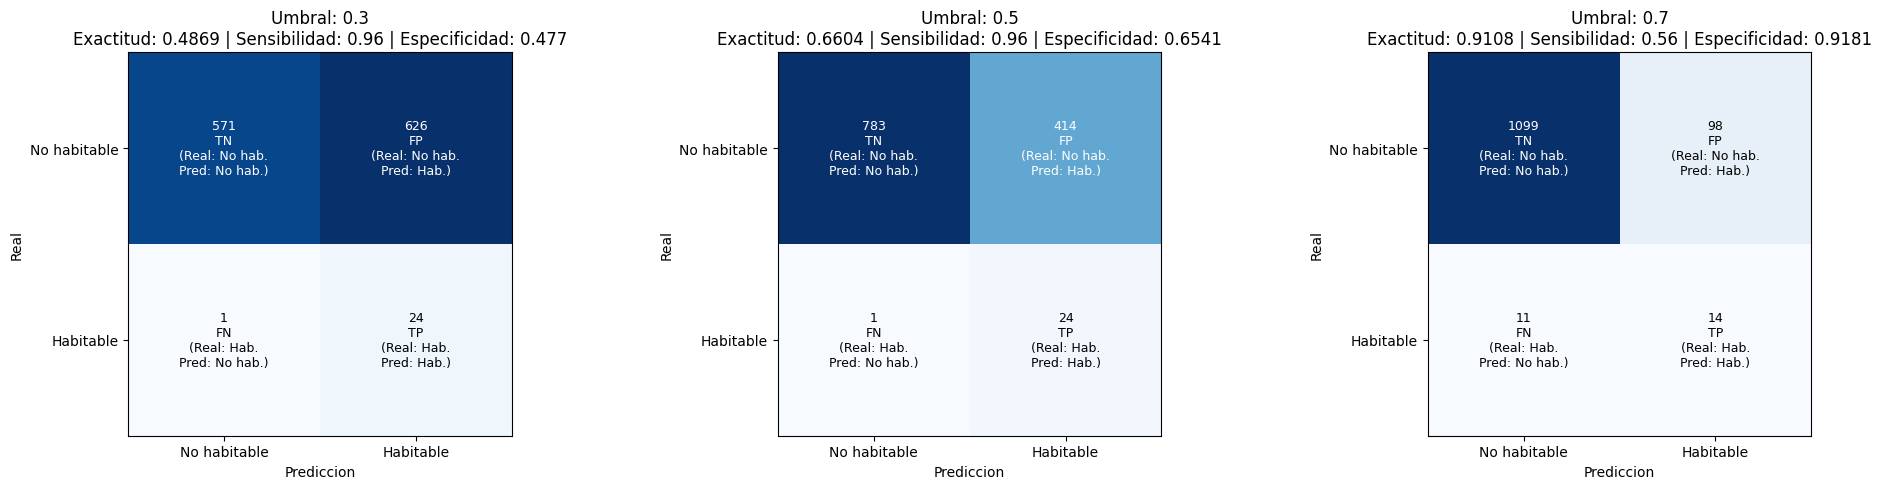

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

labels = [['TN\n(Real: No hab.\nPred: No hab.)', 'FP\n(Real: No hab.\nPred: Hab.)'],
          ['FN\n(Real: Hab.\nPred: No hab.)', 'TP\n(Real: Hab.\nPred: Hab.)']]

def evaluar_umbral(umbral, ax):
    predicciones = (probs >= umbral).astype(int)
    cm = confusion_matrix(Y_test, predicciones)
    tn, fp, fn, tp = cm.ravel()

    exactitud     = (tp + tn) / (tp + tn + fp + fn)
    sensibilidad  = tp / (tp + fn)
    especificidad = tn / (tn + fp)

    ax.imshow(cm, cmap='Blues')
    ax.set_title(f"Umbral: {umbral}\nExactitud: {round(exactitud,4)} | Sensibilidad: {round(sensibilidad,4)} | Especificidad: {round(especificidad,4)}")
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No habitable', 'Habitable'])
    ax.set_yticklabels(['No habitable', 'Habitable'])

    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f"{cm[i, j]}\n{labels[i][j]}", ha='center', va='center',
                    fontsize=9, color=color)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
evaluar_umbral(0.3, axes[0])
evaluar_umbral(0.5, axes[1])
evaluar_umbral(0.7, axes[2])

plt.tight_layout()
plt.show()

Okay, aqui vemos algo interesante, logicamente el umbral que usemos afecta mucho en nuestros resultados, vamos a interpretarlos.

### Umbral de 0.3

El modelo es muy permisivo, al parecer le cuesta clasificar los planetas, ya que 626 los predice como habitables cuando no lo son, esta balanceado con los TN, ya que 571 los clasifica como No habitables de forma correcta, tiene buena sensibilidad, pero no tiene buena exactitud ni especificidad.

### Umbral de 0.5

Aqui el modelo se vuelve un poco mas estricto a la hora de clasificar planetas,vemos que se reduce la cantidad de FP, donde ahora solo 414 los clasifica como habitables cuando NO lo eran y por consiguiente ahora los que no son habitables los puede clasificar mejor, nuestra exactitud y especificidad suben.

### Umbral de 0.7

Aqui ocurre algo interesante, ahora casi no tenemos FP en comparación con los true negative, es decir, ahora 1099 planetas que no eran habitables los identifico correctamente, 98 los identificó como habitables cuando no lo eran, vemos que tambien suben los FN, de modo que 11 los clasifica como no habitables cuando si lo eran y 14 los clasifica como habitables correctamente.

En este ultimo caso, ahora el modelo es muchisimo mas estricto para clasificar un planeta como habitable, pero al parecer es muchisimo mejor para decir que NO lo es.

Nuestra sensibilidad baja a un 0.56, peri nuestra exactitud y especificidad suben a un 0.9108 y 0.9181 respectivamente.

En general en este ultimo valor de umbral, el modelo baja su capacidad de decir que un planeta es habitable cuando realmente lo es, pero, su capacidad de decir que un planeta NO es habitable con seguridad, aumenta, lo cual en ciertos terminos puede ser util, ya que no quisieramos identificar de forma erronea algo tan drastico como la habitabilidad de un exoplaneta.



Vector de probabilidades (primeros 10):
[9.000e-04 8.787e-01 7.490e-02 4.000e-04 5.624e-01 1.471e-01 2.200e-02
 6.261e-01 3.941e-01 4.000e-04]


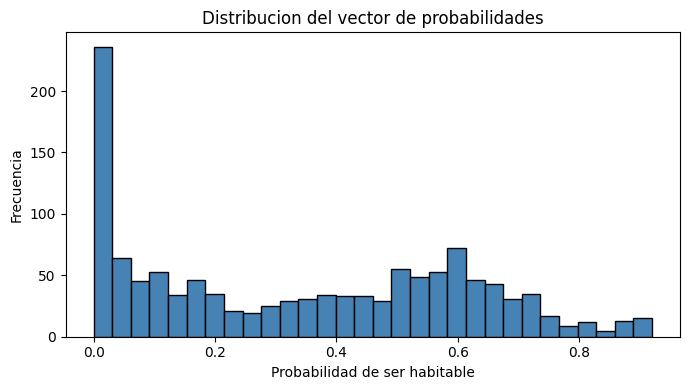

In [ ]:
# Ver los primeros valores
print("Vector de probabilidades (primeros 10):")
print(np.round(probs[:10], 4))

# Distribucion de probabilidades
plt.figure(figsize=(7, 4))
plt.hist(probs, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Probabilidad de ser habitable')
plt.ylabel('Frecuencia')
plt.title('Distribucion del vector de probabilidades')
plt.tight_layout()
plt.show()

Esta es una representación grafica del vector de probabilidades, de modo que vemos que al principio los planetas tienen una probabilidad muy baja, casi 0 de ser clasificados como habitables, conforme se reduce la frecuencia de los datos, el modelo le cuesta tomar una decisión, ya que si estuviera por asi decirlo "seguro" de sus clasificaciones, sus datos tenderian a estar hacia un lado, pero vemos que va subiendo y bajando, por lo que no es muy bueno para decidir.

Curva ROC

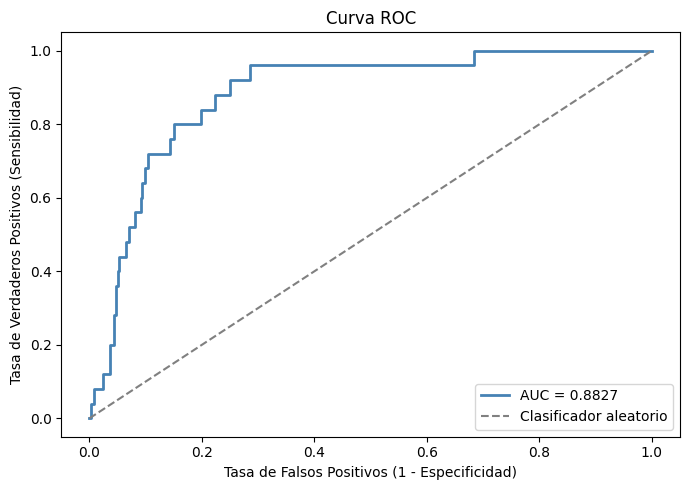


Coeficientes del modelo:
  st_rad: -0.3859 -> disminuye la probabilidad de ser habitable
  pl_insol: -2.986 -> disminuye la probabilidad de ser habitable
  st_mass: 0.4367 -> aumenta la probabilidad de ser habitable
  st_teff: -0.3155 -> disminuye la probabilidad de ser habitable
  sy_snum: 0.0 -> disminuye la probabilidad de ser habitable


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Curva ROC
fpr, tpr, thresholds = roc_curve(Y_test, probs)
auc_score = auc(fpr, tpr)

# Grafica
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {round(auc_score, 4)}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

# Coeficientes del modelo
print("\nCoeficientes del modelo:")
for feature, coef in zip(features, model.coef_[0]):
    direccion = "aumenta" if coef > 0 else "disminuye"
    print(f"  {feature}: {round(coef, 4)} -> {direccion} la probabilidad de ser habitable")

De forma generar, con la curva ROC y el AUC de 88.27% , podemos decir que el modelo es bueno distinguiendo si un planeta es habitable o no, vemos que la curva sube relativamente rapido, pudiendo inferir que es bueno no generando tantos falsos positivos.

Sin embargo, al llegar mas o menos a un 96% de sensibilidad, la curva se mantiene constante, de modo que para seguir identificando planetas, el modelo comente muchos mas errores.

###Coeficientes
Con respecto a los coeficientes, podemo decir lo siguiente:

- Las variables que mas impactan negativamente al modelo para decir si es habitable o no, son `st_teff` (temperatura efectiva de la estrella), `pl_insol`(insolación del planeta), `st_rad`(radio de la estrella) y `sy_snum`(numero de estrellas del sistema), esta ultima tiene un coeficiente de 0 por lo que podriamos decir que simplemente no es una variable relevante

- La variable que mas contribuye a que un planeta sea habitable, es `st_mass`(masa de la estrella)